## Advanced Features

### 1. Token Features

| Feature | Description |
|----------|-------------|
| `cwc_min` | Ratio of the number of common words to the length of the smaller question. |
| `cwc_max` | Ratio of the number of common words to the length of the larger question. |
| `csc_min` | Ratio of the number of common stop words to the smaller stop word count among the two questions. |
| `csc_max` | Ratio of the number of common stop words to the larger stop word count among the two questions. |
| `ctc_min` | Ratio of the number of common tokens to the smaller token count among the two questions. |
| `ctc_max` | Ratio of the number of common tokens to the larger token count among the two questions. |
| `last_word_eq` | `1` if the last word in both questions is the same, otherwise `0`. |
| `first_word_eq` | `1` if the first word in both questions is the same, otherwise `0`. |

### 2. Length Based Features

| Feature | Description |
|----------|-------------|
| `mean_len` | Mean of the length of the two questions (num of words). |
| `abs_len_diff` | Absolute difference between the length of the two questions (num of words). |
| `longest_substr_ratio` | Ratio of the length of the longest substring among the two questions to the length of the smaller question. |

### 3. Fuzzy Features

| Feature | Description |
|----------|-------------|
| `fuzz_ratio` | fuzz_ratio score from fuzzywuzzy. |
| `fuzz_partial_ratio` | fuzz_partial_ratio from fuzzywuzzy. |
| `fuzz_sort_ratio` | fuzz_sort_ratio from fuzzywuzzy. |
| `token_set_ratio` | token_set_ratio from fuzzywuzzy. |

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import string
import re
from bs4 import BeautifulSoup
from nltk.corpus import stopwords
from fuzzywuzzy import fuzz
import os
import sys

import warnings
warnings.filterwarnings('ignore')

In [34]:
# ── Add project root to path so app.config is importable ─────────────────────
PROJECT_ROOT = os.getcwd()
sys.path.append(PROJECT_ROOT)

# ── Paths ─────────────────────────────────────────────────────────────────────
INPUT_PATH  = os.path.join("../data", "quora_question_pair.csv")
OUTPUT_PATH = os.path.join("../data", "quora_question_pair_final.csv")

## Load Dataset

In [ ]:
df = pd.read_csv(INPUT_PATH)
print(df.shape)
df.head()

(404290, 6)


,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


### Taking randomly 100000 data from the dataset

In [3]:
# new_df = df.sample(10000, random_state=2)

### checking info of dataset

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404290 entries, 0 to 404289
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            404290 non-null  int64 
 1   qid1          404290 non-null  int64 
 2   qid2          404290 non-null  int64 
 3   question1     404289 non-null  object
 4   question2     404288 non-null  object
 5   is_duplicate  404290 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 18.5+ MB


### checking for null values

In [5]:
df.isnull().sum()

id              0
qid1            0
qid2            0
question1       1
question2       2
is_duplicate    0
dtype: int64

In [6]:
df.dropna(inplace=True)

### checking for duplicate values

In [7]:
df.duplicated().sum()

np.int64(0)

## Text-Preprocessing

In [8]:
def preprocess(q):
    q = str(q).lower().strip()

    # Replace certain special character with their string equivalents
    q = q.replace('%','percent')
    q = q.replace('$','dollar')
    q = q.replace('₹','rupee')
    q = q.replace('€','euro')
    q = q.replace('@','at')

    # The pattern '[math]' appears around 900 times in the whole dataset
    q = q.replace('[math]','')

    # Replcing some numbers with string equivalents (not perfect, can be done better to account for more cases)
    q = q.replace(',000,000,000 ', 'b ')
    q = q.replace(',000,000 ', 'm ')
    q = q.replace(',000 ', 'k ')
    q = re.sub(r'([0-9]+)000000000', r'\1b', q)
    q = re.sub(r'([0-9]+)000000', r'\1m', q)
    q = re.sub(r'([0-9]+)000', r'\1k', q)

    # website from which contraction words have been taken
    # https://stackoverflow.com/questions/19790188/expanding-english-language-contractions-in-python/19794953#19794953
    contractions = { 
    "ain't": "am not / are not / is not / has not / have not",
    "aren't": "are not / am not",
    "can't": "cannot",
    "can't've": "cannot have",
    "'cause": "because",
    "could've": "could have",
    "couldn't": "could not",
    "couldn't've": "could not have",
    "didn't": "did not",
    "doesn't": "does not",
    "don't": "do not",
    "hadn't": "had not",
    "hadn't've": "had not have",
    "hasn't": "has not",
    "haven't": "have not",
    "he'd": "he had / he would",
    "he'd've": "he would have",
    "he'll": "he shall / he will",
    "he'll've": "he shall have / he will have",
    "he's": "he has / he is",
    "how'd": "how did",
    "how'd'y": "how do you",
    "how'll": "how will",
    "how's": "how has / how is / how does",
    "I'd": "I had / I would",
    "I'd've": "I would have",
    "I'll": "I shall / I will",
    "I'll've": "I shall have / I will have",
    "I'm": "I am",
    "I've": "I have",
    "isn't": "is not",
    "it'd": "it had / it would",
    "it'd've": "it would have",
    "it'll": "it shall / it will",
    "it'll've": "it shall have / it will have",
    "it's": "it has / it is",
    "let's": "let us",
    "ma'am": "madam",
    "mayn't": "may not",
    "might've": "might have",
    "mightn't": "might not",
    "mightn't've": "might not have",
    "must've": "must have",
    "mustn't": "must not",
    "mustn't've": "must not have",
    "needn't": "need not",
    "needn't've": "need not have",
    "o'clock": "of the clock",
    "oughtn't": "ought not",
    "oughtn't've": "ought not have",
    "shan't": "shall not",
    "sha'n't": "shall not",
    "shan't've": "shall not have",
    "she'd": "she had / she would",
    "she'd've": "she would have",
    "she'll": "she shall / she will",
    "she'll've": "she shall have / she will have",
    "she's": "she has / she is",
    "should've": "should have",
    "shouldn't": "should not",
    "shouldn't've": "should not have",
    "so've": "so have",
    "so's": "so as / so is",
    "that'd": "that would / that had",
    "that'd've": "that would have",
    "that's": "that has / that is",
    "there'd": "there had / there would",
    "there'd've": "there would have",
    "there's": "there has / there is",
    "they'd": "they had / they would",
    "they'd've": "they would have",
    "they'll": "they shall / they will",
    "they'll've": "they shall have / they will have",
    "they're": "they are",
    "they've": "they have",
    "to've": "to have",
    "wasn't": "was not",
    "we'd": "we had / we would",
    "we'd've": "we would have",
    "we'll": "we will",
    "we'll've": "we will have",
    "we're": "we are",
    "we've": "we have",
    "weren't": "were not",
    "what'll": "what shall / what will",
    "what'll've": "what shall have / what will have",
    "what're": "what are",
    "what's": "what has / what is",
    "what've": "what have",
    "when's": "when has / when is",
    "when've": "when have",
    "where'd": "where did",
    "where's": "where has / where is",
    "where've": "where have",
    "who'll": "who shall / who will",
    "who'll've": "who shall have / who will have",
    "who's": "who has / who is",
    "who've": "who have",
    "why's": "why has / why is",
    "why've": "why have",
    "will've": "will have",
    "won't": "will not",
    "won't've": "will not have",
    "would've": "would have",
    "wouldn't": "would not",
    "wouldn't've": "would not have",
    "y'all": "you all",
    "y'all'd": "you all would",
    "y'all'd've": "you all would have",
    "y'all're": "you all are",
    "y'all've": "you all have",
    "you'd": "you had / you would",
    "you'd've": "you would have",
    "you'll": "you shall / you will",
    "you'll've": "you shall have / you will have",
    "you're": "you are",
    "you've": "you have"
    }
    
    q_decontracted = []
    for word in q.split():
        if word in contractions:
            word = contractions[word]
        q_decontracted.append(word)
    
    q = ' '.join(q_decontracted)
    q = q.replace("'ve"," have")
    q = q.replace("n't"," not")
    q = q.replace("'re"," are")
    q = q.replace("'ll"," will")
    
    # Removing HTML Tags
    q = BeautifulSoup(q)
    q = q.get_text()
    
    # Remove Punctualtions
    
    pattern = re.compile('\W')
    q = re.sub(pattern,' ', q).strip()
        
    exclude = string.punctuation
    q = q.translate(str.maketrans('','',exclude))

    return q

In [9]:
# Applyting text-preprocessing to question pairs
df['question1'] = df['question1'].apply(preprocess)
df['question2'] = df['question2'].apply(preprocess)

In [10]:
df.head()

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,what is the step by step guide to invest in sh...,what is the step by step guide to invest in sh...,0
1,1,3,4,what is the story of kohinoor koh i noor dia...,what would happen if the indian government sto...,0
2,2,5,6,how can i increase the speed of my internet co...,how can internet speed be increased by hacking...,0
3,3,7,8,why am i mentally very lonely how can i solve it,find the remainder when 23 24 math is divi...,0
4,4,9,10,which one dissolve in water quikly sugar salt...,which fish would survive in salt water,0


In [11]:
qid = pd.Series(df['qid1'].to_list() + df['qid2'].to_list())
print("Number of unique questions : ",np.unique(qid).shape[0])
x = qid.value_counts() > 1
print("Number of questions getting repeated : ", x[x].shape[0])

Number of unique questions :  537929
Number of questions getting repeated :  111778


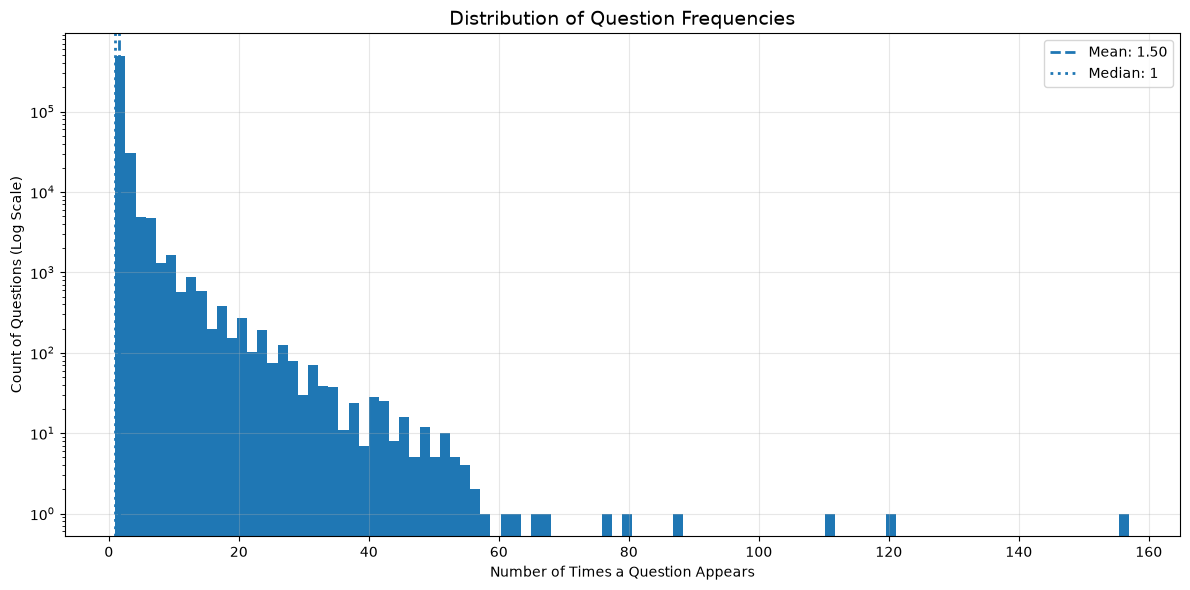

Maximum repetitions : 157
Average repetitions : 1.50
Median repetitions  : 1


In [12]:
# Repeated questions histogram
question_freq = qid.value_counts().values

plt.figure(figsize=(12, 6))

plt.hist(question_freq, bins=100)

plt.yscale('log')

plt.title('Distribution of Question Frequencies', fontsize=14)
plt.xlabel('Number of Times a Question Appears')
plt.ylabel('Count of Questions (Log Scale)')

plt.axvline(
    np.mean(question_freq),
    linestyle='--',
    linewidth=2,
    label=f'Mean: {np.mean(question_freq):.2f}'
)

plt.axvline(
    np.median(question_freq),
    linestyle=':',
    linewidth=2,
    label=f'Median: {np.median(question_freq):.0f}'
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()
print(f"Maximum repetitions : {question_freq.max():,}")
print(f"Average repetitions : {question_freq.mean():.2f}")
print(f"Median repetitions  : {np.median(question_freq):.0f}")

## Custom/Basic Features

### Length of question1 and question2

In [13]:
df['q1_len'] = df['question1'].str.len()
df['q2_len'] = df['question2'].str.len()
df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len
0,0,1,2,what is the step by step guide to invest in sh...,what is the step by step guide to invest in sh...,0,65,56
1,1,3,4,what is the story of kohinoor koh i noor dia...,what would happen if the indian government sto...,0,50,87
2,2,5,6,how can i increase the speed of my internet co...,how can internet speed be increased by hacking...,0,72,58
3,3,7,8,why am i mentally very lonely how can i solve it,find the remainder when 23 24 math is divi...,0,49,58
4,4,9,10,which one dissolve in water quikly sugar salt...,which fish would survive in salt water,0,75,38


### Number of words in question1 and question2

In [14]:
df['q1_num_words'] = df['question1'].apply(lambda x: len(x.split(" ")))
df['q2_num_words'] = df['question2'].apply(lambda x: len(x.split(" ")))
df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words
0,0,1,2,what is the step by step guide to invest in sh...,what is the step by step guide to invest in sh...,0,65,56,14,12
1,1,3,4,what is the story of kohinoor koh i noor dia...,what would happen if the indian government sto...,0,50,87,12,17
2,2,5,6,how can i increase the speed of my internet co...,how can internet speed be increased by hacking...,0,72,58,14,10
3,3,7,8,why am i mentally very lonely how can i solve it,find the remainder when 23 24 math is divi...,0,49,58,12,16
4,4,9,10,which one dissolve in water quikly sugar salt...,which fish would survive in salt water,0,75,38,15,7


### Common Words

In [15]:
# function to find number of common words between question1 and question2
def common_words(row):
    w1 = set(map(lambda word:word.lower().strip(), row['question1'].split(" ")))
    w2 = set(map(lambda word:word.lower().strip(), row['question2'].split(" ")))
    return len(w1 & w2)

In [16]:
# number of common words between question1 and question2
df['word_common'] = df.apply(common_words, axis=1)
df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common
0,0,1,2,what is the step by step guide to invest in sh...,what is the step by step guide to invest in sh...,0,65,56,14,12,11
1,1,3,4,what is the story of kohinoor koh i noor dia...,what would happen if the indian government sto...,0,50,87,12,17,8
2,2,5,6,how can i increase the speed of my internet co...,how can internet speed be increased by hacking...,0,72,58,14,10,4
3,3,7,8,why am i mentally very lonely how can i solve it,find the remainder when 23 24 math is divi...,0,49,58,12,16,1
4,4,9,10,which one dissolve in water quikly sugar salt...,which fish would survive in salt water,0,75,38,15,7,4


### Total Words

In [17]:
# function to find total number of unique words in both questions combined
def total_words(row):
    w1 = set(map(lambda word:word.lower().strip(), row['question1'].split(" ")))
    w2 = set(map(lambda word:word.lower().strip(), row['question2'].split(" ")))
    return (len(w1) + len(w2))

In [18]:
# Total number of unique words in both questions combined
df['word_total'] = df.apply(total_words,axis=1)
df.head(3)

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total
0,0,1,2,what is the step by step guide to invest in sh...,what is the step by step guide to invest in sh...,0,65,56,14,12,11,23
1,1,3,4,what is the story of kohinoor koh i noor dia...,what would happen if the indian government sto...,0,50,87,12,17,8,26
2,2,5,6,how can i increase the speed of my internet co...,how can internet speed be increased by hacking...,0,72,58,14,10,4,24


### Word Share

In [19]:
df['word_share'] = round(df['word_common']/df['word_total'],2)
df.head(3)

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total,word_share
0,0,1,2,what is the step by step guide to invest in sh...,what is the step by step guide to invest in sh...,0,65,56,14,12,11,23,0.48
1,1,3,4,what is the story of kohinoor koh i noor dia...,what would happen if the indian government sto...,0,50,87,12,17,8,26,0.31
2,2,5,6,how can i increase the speed of my internet co...,how can internet speed be increased by hacking...,0,72,58,14,10,4,24,0.17


## Advanced Features

### Token Features

In [20]:
def fetch_token_features(row):
    
    q1 = row['question1']
    q2 = row['question2']
    
    SAFE_DIV = 0.0001
    
    STOP_WORDS = stopwords.words('english')

    token_features = [0.0]*8

    # Converting the sentence into tokens
    q1_tokens = q1.split()
    q2_tokens = q2.split()

    if len(q1_tokens) == 0 or len(q2_tokens) == 0:
        return token_features
    
    # Get the non-stopwords in question1
    q1_words = set([word for word in q1_tokens if word not in STOP_WORDS])
    q2_words = set([word for word in q2_tokens if word not in STOP_WORDS])

    # Get the stopwords in question1
    q1_stops = set([word for word in q1_tokens if word in STOP_WORDS])
    q2_stops = set([word for word in q2_tokens if word in STOP_WORDS])

    # Get the common non-stopwords from Question pair
    common_word_count = len(q1_words.intersection(q2_words))

    # Get the common stopwords from Question pair
    common_stop_count = len(q1_stops.intersection(q2_stops))

    # Get the common tokens from Question pair
    common_token_count = len(set(q1_tokens).intersection(set(q2_tokens)))

    token_features[0] = common_word_count / (min(len(q1_words), len(q2_words)) + SAFE_DIV)
    token_features[1] = common_word_count / (max(len(q1_words), len(q2_words)) + SAFE_DIV)
                                             
    token_features[2] = common_stop_count / (min(len(q1_stops), len(q2_stops)) + SAFE_DIV)
    token_features[3] = common_stop_count / (max(len(q1_stops), len(q2_stops)) + SAFE_DIV)
                                             
    token_features[4] = common_token_count / (min(len(q1_tokens), len(q2_tokens)) + SAFE_DIV)
    token_features[5] = common_token_count / (min(len(q1_tokens), len(q2_tokens)) + SAFE_DIV)

    # Last word of both questions is same or not 
    token_features[6] = int(q1_tokens[-1] == q2_tokens[-1])

    # First word of both questions is same or not 
    token_features[7] = int(q1_tokens[0] == q2_tokens[0])

    return token_features
     

In [21]:
token_features = df.apply(fetch_token_features, axis=1)

df['cwc_min'] = list(map(lambda x: x[0], token_features))
df['cwc_max'] = list(map(lambda x: x[1], token_features))
df['csc_min'] = list(map(lambda x: x[2], token_features))
df['csc_max'] = list(map(lambda x: x[3], token_features))
df['ctc_min'] = list(map(lambda x: x[4], token_features))
df['ctc_max'] = list(map(lambda x: x[5], token_features))
df['last_word_eq'] = list(map(lambda x: x[6], token_features))
df['first_word_eq'] = list(map(lambda x: x[7], token_features))

In [22]:
token_features

0         [0.999980000399992, 0.8333194446759221, 0.9999...
1         [0.7999840003199936, 0.39999600003999963, 0.74...
2         [0.3999920001599968, 0.3333277778703688, 0.399...
3                      [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0, 0]
4         [0.3999920001599968, 0.19999800001999982, 0.99...
                                ...                        
404285    [0.8571306124198226, 0.8571306124198226, 0.999...
404286    [0.6666444451851604, 0.6666444451851604, 0.599...
404287    [0.9999000099990001, 0.49997500124993743, 0.99...
404288    [0.0, 0.0, 0.124998437519531, 0.09999900000999...
404289    [0.9999666677777407, 0.9999666677777407, 0.999...
Length: 404287, dtype: object

### Length Based Features

In [23]:
import distance
def fetch_length_features(row):

    q1 = row['question1']
    q2 = row['question2']

    length_features = [0.0]*3

    # Converting the sentence into tokens
    q1_tokens = q1.split()
    q2_tokens = q2.split()

    if len(q1_tokens) == 0 or len(q2_tokens) == 0 :
        return length_features

    # absolute length feature
    length_features[0] = abs(len(q1_tokens) - len(q2_tokens))

    # Average token length of both Questions
    length_features[1] = (len(q1_tokens) + len(q2_tokens)) / 2

    strs = list(distance.lcsubstrings(q1,q2))
    
    # strs[0] will raise indexOutOfBound exception when there is no common string (i.e strs = [])
    
    if strs:                     # when common string present
        length_features[2] = len(strs[0]) / (min(len(q1), len(q2)) + 1)
    else:
        length_features[2] = 0.0   # no common string
        
    return length_features

In [24]:
length_features = df.apply(fetch_length_features, axis=1)

df['abs_len_diff'] = list(map(lambda x: x[0], length_features))
df['mean_len'] = list(map(lambda x: x[1], length_features))
df['longest_substr_ratio'] = list(map(lambda x: x[2], length_features))


Caching the list of root modules, please wait!
(This will only be done once - type '%rehashx' to reset cache!)


Caching the list of root modules, please wait!
(This will only be done once - type '%rehashx' to reset cache!)


Caching the list of root modules, please wait!
(This will only be done once - type '%rehashx' to reset cache!)



In [25]:
df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,...,cwc_max,csc_min,csc_max,ctc_min,ctc_max,last_word_eq,first_word_eq,abs_len_diff,mean_len,longest_substr_ratio
0,0,1,2,what is the step by step guide to invest in sh...,what is the step by step guide to invest in sh...,0,65,56,14,12,...,0.833319,0.999983,0.999983,0.916659,0.916659,0.0,1.0,2.0,13.0,0.982456
1,1,3,4,what is the story of kohinoor koh i noor dia...,what would happen if the indian government sto...,0,50,87,12,17,...,0.399996,0.749981,0.599988,0.699993,0.699993,0.0,1.0,5.0,12.5,0.588235
2,2,5,6,how can i increase the speed of my internet co...,how can internet speed be increased by hacking...,0,72,58,14,10,...,0.333328,0.399992,0.249997,0.399996,0.399996,0.0,1.0,4.0,12.0,0.169492
3,3,7,8,why am i mentally very lonely how can i solve it,find the remainder when 23 24 math is divi...,0,49,58,12,16,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,1.0,11.5,0.040000
4,4,9,10,which one dissolve in water quikly sugar salt...,which fish would survive in salt water,0,75,38,15,7,...,0.199998,0.999950,0.666644,0.571420,0.571420,0.0,1.0,6.0,10.0,0.153846


### Fuzzy Features

In [27]:
def fetch_fuzzy_features(row):

    q1 = row['question1']
    q2 = row['question2']

    fuzzy_features = [0.0]*4

    # fuzz_ratio
    fuzzy_features[0] = fuzz.QRatio(q1, q2)

    # fuzz_partial_ratio
    fuzzy_features[1] = fuzz.partial_ratio(q1, q2)

    # token_sort_ratio
    fuzzy_features[2] = fuzz.token_sort_ratio(q1, q2)

    # token_set_ratio
    fuzzy_features[3] = fuzz.token_set_ratio(q1, q2)

    return fuzzy_features

In [28]:
fuzzy_features = df.apply(fetch_fuzzy_features, axis=1)

# Creating new feature names for fuzzy feaures
df['fuzz_ratio'] = list(map(lambda x:x[0], fuzzy_features))
df['fuzz_partial_ratio'] = list(map(lambda x:x[1], fuzzy_features))
df['token_sort_ratio'] = list(map(lambda x:x[2], fuzzy_features))
df['token_set_ratio'] = list(map(lambda x:x[3], fuzzy_features))

In [29]:
print(df.shape)
df.head(3)

(404287, 28)


,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,...,ctc_max,last_word_eq,first_word_eq,abs_len_diff,mean_len,longest_substr_ratio,fuzz_ratio,fuzz_partial_ratio,token_sort_ratio,token_set_ratio
0,0,1,2,what is the step by step guide to invest in sh...,what is the step by step guide to invest in sh...,0,65,56,14,12,...,0.916659,0.0,1.0,2.0,13.0,0.982456,93,100,93,100
1,1,3,4,what is the story of kohinoor koh i noor dia...,what would happen if the indian government sto...,0,50,87,12,17,...,0.699993,0.0,1.0,5.0,12.5,0.588235,66,74,63,86
2,2,5,6,how can i increase the speed of my internet co...,how can internet speed be increased by hacking...,0,72,58,14,10,...,0.399996,0.0,1.0,4.0,12.0,0.169492,54,53,66,66


## Save Feature Engineered Dataset

In [ ]:
df.to_csv(OUTPUT_PATH, index=False)